In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import scipy

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.manifold import TSNE

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Input, Dense, LSTM,Conv2D,Reshape,Flatten,MaxPooling2D,GlobalAveragePooling2D, BatchNormalization, concatenate, UpSampling2D, GlobalAveragePooling1D,GlobalMaxPooling2D, AveragePooling2D
from keras.models import Model
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, Flatten
from keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, accuracy_score

from docx import Document
from docx.shared import Inches
from docx.shared import Pt
from sklearn.metrics import classification_report

# Feature Alignment using various size of MaxPooling layer


In [371]:
max_entries_per_file = 120000
df = pd.DataFrame(columns=['DE_data', 'fault'])

# Input the file names manually
file_names_to_select = ['Normal 0.mat','OR007@6 0.mat', 'B007 0.mat', 'IR007 0.mat' ]  
# file_names_to_select = ['Normal 2.mat','B007 2.mat', 'B014 2.mat', 'B021 2.mat' ]  

for file_name in file_names_to_select:
    path = os.path.join("/IITR/Dataset/CWRU", file_name)
    print(path)

    mat = scipy.io.loadmat(path)

    if file_name == 'Normal 2.mat':
        key_name = list(mat.keys())[4]
    else:
        key_name = list(mat.keys())[3]
    
    print(key_name)
    DE_data = mat.get(key_name)
    fault = np.full((len(DE_data), 1), file_name[:-4])

    df_temp = pd.DataFrame({'DE_data': np.ravel(DE_data), 'fault': np.ravel(fault)})

    if len(df_temp) <= max_entries_per_file:
        df = pd.concat([df, df_temp], axis=0)
    else:
        df = pd.concat([df, df_temp.head(max_entries_per_file)], axis=0)


/IITR/Dataset/CWRU\Normal 0.mat
X097_DE_time
/IITR/Dataset/CWRU\OR007@6 0.mat
X130_DE_time
/IITR/Dataset/CWRU\B007 0.mat
X118_DE_time
/IITR/Dataset/CWRU\IR007 0.mat
X105_DE_time


C:\Users\akhta\AppData\Local\Temp\ipykernel_30464\3984229194.py:28: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, df_temp.head(max_entries_per_file)], axis=0)


In [372]:
# Add the name of the csv
motor_load = '2hp'
csv_filename = f'{motor_load}.csv'
df.to_csv(csv_filename, index=False)

In [423]:
win_len=1024
stride=512
# win_len=2048
# stride=1024

X=[]
Y=[]

for faults in df['fault'].unique():
    
    df_temp_2 = df[df['fault']==faults]
    
    for i in np.arange(0,len(df_temp_2)-(win_len),stride):
        temp = df_temp_2.iloc[i:i+win_len,:-1].values
        X.append(temp)
        Y.append(df_temp_2.iloc[i+win_len,-1])
    
X=np.array(X)
X=X.reshape((X.shape[0],win_len))

Y=np.array(Y)
encoder= LabelEncoder()
encoder.fit(Y)
encoded_Y = encoder.transform(Y)
OHE_Y = to_categorical(encoded_Y)

In [424]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,OHE_Y,test_size=0.3,shuffle=True)    

In [425]:
print(f'Training Data Shape: {X_train.shape}')
print(f'Testing Data Shape:{X_test.shape}')

Training Data Shape: (652, 1024)
Testing Data Shape:(280, 1024)


### Train 4 CNN layers with filter size [9, 17, 33, 65] parallely ➡️ calculate RF ➡️ use maxpooling >= RF ➡️ GAP ➡️ FC layer


In [426]:
input_layer = Input(shape=(win_len,1))

# Implement parallel convolutional layers with different kernel sizes
conv_1 = Conv1D(filters=64, kernel_size=9, padding='same', activation='relu')(input_layer)
conv_2 = Conv1D(filters=64, kernel_size=17, padding='same', activation='relu')(input_layer)
conv_3 = Conv1D(filters=64, kernel_size=33, padding='same', activation='relu')(input_layer)
conv_4 = Conv1D(filters=64, kernel_size=65, padding='same', activation='relu')(input_layer)

# Concatenate the output feature maps from all convolutional layers
concatenated = concatenate([conv_1, conv_2, conv_3, conv_4],axis=-1)

In [427]:
BPFI = 159.93   # ball pass frequency inner race
BPFO = 105.8    # ball pass frequency outer
FTF = 11.76     # fundamental train frequency
BSF = 3.13      # ball spin frequency
fs =  12        # sampling frequency
lambda_ = 1.05  # correction coefficient

# Calculate RF
FFFs = [BPFI, BPFO, FTF, BSF]
RF = np.ceil(lambda_ * fs / min(FFFs))

In [428]:
print(RF)

5.0


In [429]:
# max-pooling layer with calculated RF
max_pooling = MaxPooling1D(pool_size=int(RF))(concatenated)  

# Add Global Average Pooling layer
global_avg_pooling = GlobalAveragePooling1D()(max_pooling)

dense_layer_2 = Dense(100, activation='relu')(global_avg_pooling)

output_layer = Dense(4, activation='softmax')(dense_layer_2)


model = Model(inputs=input_layer, outputs=output_layer)


model.summary()

Model: "model_53"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_62 (InputLayer)          [(None, 1024, 1)]    0           []                               
                                                                                                  
 conv1d_24 (Conv1D)             (None, 1024, 64)     640         ['input_62[0][0]']               
                                                                                                  
 conv1d_25 (Conv1D)             (None, 1024, 64)     1152        ['input_62[0][0]']               
                                                                                                  
 conv1d_26 (Conv1D)             (None, 1024, 64)     2176        ['input_62[0][0]']               
                                                                                           

In [430]:
from keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(monitor='val_loss', 
                              factor=0.1, 
                              patience=5, 
                              min_lr=1e-10, 
                              verbose=1)

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(X_train, y_train, 
                    epochs=20, 
                    batch_size=32, 
                    validation_split=0.2,
                    callbacks=[reduce_lr])

# Evaluate the model on test data
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test Accuracy: {accuracy}')

Epoch 1/20
17/17 [==============================] - 1s 27ms/step - loss: 1.2189 - accuracy: 0.3359 - val_loss: 1.0322 - val_accuracy: 0.4809 - lr: 0.0010
Epoch 2/20
17/17 [==============================] - 0s 9ms/step - loss: 0.9758 - accuracy: 0.6161 - val_loss: 0.7838 - val_accuracy: 0.9771 - lr: 0.0010
Epoch 3/20
17/17 [==============================] - 0s 9ms/step - loss: 0.6794 - accuracy: 1.0000 - val_loss: 0.4510 - val_accuracy: 1.0000 - lr: 0.0010
Epoch 4/20
17/17 [==============================] - 0s 9ms/step - loss: 0.3400 - accuracy: 1.0000 - val_loss: 0.1824 - val_accuracy: 1.0000 - lr: 0.0010
Epoch 5/20
17/17 [==============================] - 0s 10ms/step - loss: 0.1223 - accuracy: 1.0000 - val_loss: 0.0603 - val_accuracy: 1.0000 - lr: 0.0010
Epoch 6/20
17/17 [==============================] - 0s 9ms/step - loss: 0.0454 - accuracy: 1.0000 - val_loss: 0.0264 - val_accuracy: 1.0000 - lr: 0.0010
Epoch 7/20
17/17 [==============================] - 0s 9ms/step - loss: 0.0221 -

In [431]:
num_epochs = len(history.history['accuracy'])
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

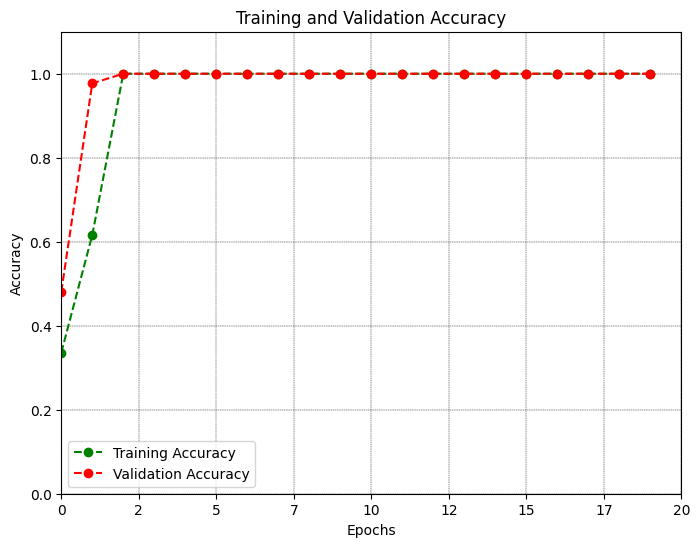

In [432]:
plt.figure(figsize=(8, 6))  

plt.plot( train_acc, 'go--', label='Training Accuracy')
plt.plot( val_acc, 'ro--', label='Validation Accuracy')

plt.legend(loc='best')

plt.grid(color='k', linestyle='--', linewidth=0.3)

plt.title('Training and Validation Accuracy')

plt.xlabel('Epochs')

plt.ylabel('Accuracy')

plt.xlim(0, num_epochs)  
plt.gca().xaxis.set_major_formatter(plt.matplotlib.ticker.FormatStrFormatter('%d'))  # Use '%d' for integers
plt.ylim(0, 1.1)  

# Display the plot
plt.show()

9/9 [==============================] - 0s 37ms/step


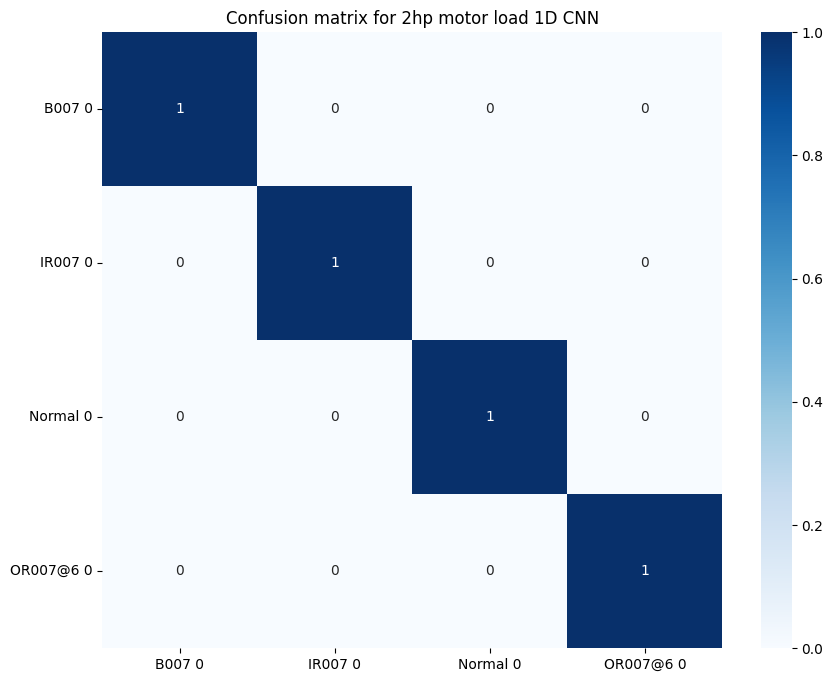

In [433]:
# Predictions and confusion matrix
y_pred = model.predict(X_test)

# Assuming encoder.classes_ contains the class labels
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

# Create confusion matrix
cm = confusion_matrix(y_true_labels, y_pred_labels, normalize='true')

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, xticklabels=encoder.classes_, yticklabels=encoder.classes_, cmap=plt.cm.Blues)
plt.title(f'Confusion matrix for {motor_load} motor load 1D CNN')
plt.yticks(rotation=0)
plt.show()